# Lecture 2 (UFO and HofX)

## Learning Objectives

By the end of this lecture, you will be able to:

- Explain the role of observation operators in JEDI

- Describe what GeoVaLs are and how model interfaces (e.g., FV3-JEDI, MPAS-JEDI) compute them from model fields on different grids

- Set up and run a JEDI HofX application, including configuring the input YAML for geometry, model state, observations, and observation operator

- Interpret feedback files produced by an HofX run and compare observed values with model equivalents (H(x))

- Apply observation filters (e.g., `RejectList`) in the YAML configuration and understand how QC flags in the feedback file control which observations are used in assimilation

- Navigate the fv3-jedi repository to find HofX ctest examples and use them as references for building your own applications

<div style="text-align: center;">
    <img src="./figures/HofX.png" width="75%">
</div>

## Observation operators in JEDI

* Observation operators calculate model equivalent values at observation locations and times.
  
* For simple cases, observation operators may only perform an interpolation ([Vertical interpolation](https://jointcenterforsatellitedataassimilation-jedi-docs.readthedocs-hosted.com/en/latest/inside/jedi-components/ufo/obsops.html#vertical-interpolation)).

* When the observed quantity is not directly represented in the model state the observation operator will perform more complex calculations to compute the observed quantity. This is often the case in satellite observations. For example, [Column retrieval operator](https://jointcenterforsatellitedataassimilation-jedi-docs.readthedocs-hosted.com/en/latest/inside/jedi-components/ufo/obsops.html#column-retrieval-operator) can calculate tropospheric (or total) column of NO2 or CO from model inputs at observation locations.

* Observation operators are organized with the [Unified Forward Operator (UFO)](https://github.com/JCSDA/ufo/tree/develop).

* To run an observation operator we run a JEDI H(x) application. 

## Model interfaces and GeoVaLs

* GeoVaLs (Model values at observations locations) are 2D columns (location x level) and represent model fields interpolated to the locations (and time) of observations.
  
* GeoVaLs are computed through model specific interfaces. For example, for GEOS models FV3-jedi interface handles reading of the model files in cubed-sphere and computing GeoVaLs at desired location. Similarly, MPAS-jedi interface handles model files in the mpas grid and computes the GeoVaLs at desired location.

* This way the GeoVaLs format remains consistent regardless of the grid configuration of the inputs.

* Observation operators in JEDI take GeoVaLs (model state) and observation in IODA format as inputs and compute the model equivalents values as the output in **feedback** files.

* In general, users do not need to interact with GeoVaLs directly, as they are part of JEDI's internal interface.

## Running a JEDI HofX application

Let's go over an HofX 3D example using TEMPO tropospheric NO2 and the Column Retrieval observation operator.

To run an HofX 3D example, you run the relevant JEDI executable, `fv3jedi_hofx_nomodel.x` with a YAML intput file. In the YAML you must specify:

* Assimilation window
* Geometry of your inputs
* Information about the input backgrounds (model state) and state variables
* Information about the observation file
* Information about the observation operator.

Here is an example of the input YAML:

```yaml
# Beginning and length of assimilation window
time window:
  begin: '2023-08-09T15:00:00Z'
  length: PT6H

# Geometry of the state or background
geometry:
  fms initialization:
    namelist filename: ../inputs/geometry_input/fmsmpp.nml
  akbk: ../inputs/geometry_input/akbk72.nc4
  npx: 91
  npy: 91
  npz: 72

# Model state valid in the middle of the assimilation window
state:
  datetime: '2023-08-09T18:00:00Z'
  filetype: cube sphere history
  datapath: ../inputs/backgrounds/bkg/c90
  filename: CF2.geoscf_jedi.20230809T180000Z.nc4
  state variables:
  - air_pressure_thickness
  - volume_mixing_ratio_of_no2
  - volume_mixing_ratio_of_no
  - volume_mixing_ratio_of_o3
  - air_pressure_at_surface
  field io names:
    air_pressure_thickness: DELP
    volume_mixing_ratio_of_no: 'NO'
    volume_mixing_ratio_of_no2: NO2
    volume_mixing_ratio_of_o3: O3
    air_pressure_at_surface: PS
  max allowable geometry difference: 0.1

# Observations measured within the assimilation window
# But are assumed to be valid in the middle of the assimilation window.
observations:
  observers:
  - obs space:
      name: tempo_no2_tropo
      obsdatain:
        engine:
          obsfile: ../inputs/obs/tempo_no2_tropo_20230809T150000Z.nc
          type: H5File
      obsdataout:
        engine:
          allow overwrite: true
          obsfile: outputs/fb.hofx3d.tempo_no2_tropo.20230809T150000Z.nc
          type: H5File
      observed variables:
      - nitrogendioxideColumn
      simulated variables:
      - nitrogendioxideColumn

    obs operator:
      name: ColumnRetrieval
      isApriori: false
      isAveragingKernel: true
      nlayers_retrieval: 72
      stretchVertices: topbottom
      tracer variables:
      - volume_mixing_ratio_of_no2
```

The JEDI executable can be run:

```bash
$MPIEXEC "-n" "6" $JEDI_BUILD/<jediexecutable>.x <yourapplicationyaml>.yaml 2>&1 | tee <alogfile>.txt```

[The hofx3D practical example](https://mer-a-o.github.io/howtojedi/run-hofx3d/) provides details of setting up the environment and running an hofx application for a low resolution test case.

`obsdataout` specifies the name of the output feedback file. Let's review this file. 

```yaml
      obsdataout:
        engine:
          allow overwrite: true
          obsfile: outputs/fb.hofx3d.tempo_no2_tropo.20230809T150000Z.nc
          type: H5File
```

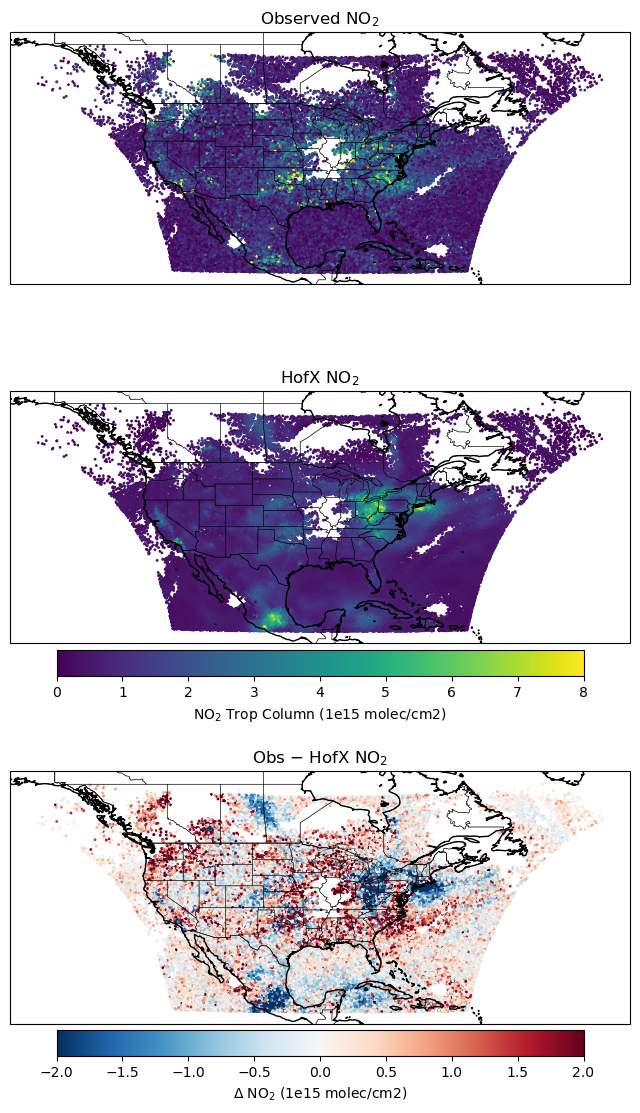

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors

live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
fb_filename = f'{live_demo_path}/hofx/outputs/fb.hofx3d.tempo_no2_tropo.20230809T150000Z.nc'
obs_file = xr.open_datatree(fb_filename)
var_name = 'nitrogendioxideColumn'
obs = obs_file['ObsValue'][var_name]
hofx = obs_file['hofx'][var_name]
lat = obs_file['MetaData']['latitude']
lon = obs_file['MetaData']['longitude']

# Convert from mol/m2 to 1e15 molec/cm2 for plotting
conv = 60221.4076
unit = '(1e15 molec/cm2)'

# Color scales
norm_main = colors.Normalize(vmin=0, vmax=8)
norm_diff = colors.TwoSlopeNorm(vcenter=0, vmin=-2, vmax=2)

cmap_main = 'viridis'
cmap_diff = 'RdBu_r'

# Plotting
fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(8, 14),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Common features
for ax in axes:
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

# ---- Panel 1: Obs ----
sc0 = axes[0].scatter(
    lon, lat,
    cmap=cmap_main, norm=norm_main,
    c=conv*obs,
    s=1,
    transform=ccrs.PlateCarree()
)
axes[0].set_title('Observed NO$_2$')


# ---- Panel 2: HofX ----
sc1 = axes[1].scatter(
    lon, lat,
    cmap=cmap_main, norm=norm_main,
    c=conv*hofx,
    s=1,
    transform=ccrs.PlateCarree()
)
axes[1].set_title('HofX NO$_2$')


# ---- Panel 2: omb ----
sc2 = axes[2].scatter(
    lon, lat,
    cmap=cmap_diff, norm=norm_diff,
    c=conv*(obs - hofx),
    s=1,
    transform=ccrs.PlateCarree()
)
axes[2].set_title('Obs − HofX NO$_2$')

# ---- Colorbars ----
cbar1 = fig.colorbar(
    sc1, ax=axes[1],
    orientation='horizontal',
    pad=0.02, shrink=0.85
)
cbar1.set_label(f'NO$_2$ Trop Column {unit}')

cbar2 = fig.colorbar(
    sc2, ax=axes[2],
    orientation='horizontal',
    pad=0.02, shrink=0.85
)
cbar2.set_label(f'Δ NO$_2$ {unit}')


plt.show()

## Running a JEDI HofX application with filters

* To use filters you can add them to the `observers` section of the input YAML.
* More about the filters in JEDI is available in the [documentation](https://jointcenterforsatellitedataassimilation-jedi-docs.readthedocs-hosted.com/en/latest/inside/jedi-components/ufo/qcfilters/GenericQC.html#generic-qc-filters).
* In this example, let's filter out pixels with Solar Zenith Angle (SZA) greater than 70deg and Cloud Fraction (CF) greater than 0.15. Are SZA and CF available in the observation IODA file? 

In [1]:
def print_groups(ioda_filename):
    # Loop through each group in the file
    for group_name in ioda_filename.groups:
        print(f"\n=== Group: {group_name} ===")
    
        group = ioda_filename[group_name]
    
        # List data variables
        if group.data_vars:
            print("  Data variables:")
            for var in group.data_vars:
                print(f"    - {var}")
        else:
            print("  Data variables: None")

In [4]:
import xarray as xr
live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
obs_filename = f'{live_demo_path}/inputs/obs/tempo_no2_tropo_20230809T150000Z.nc'
obs_file = xr.open_datatree(obs_filename)
print_groups(obs_file)


=== Group: / ===
  Data variables: None

=== Group: /MetaData ===
  Data variables:
    - albedo
    - cloud_fraction
    - dateTime
    - latitude
    - longitude
    - quality_assurance_value
    - solar_zenith_angle
    - viewing_zenith_angle

=== Group: /ObsError ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /ObsValue ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /PreQC ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /RetrievalAncillaryData ===
  Data variables:
    - averagingKernel
    - pressureVertice


`solar_zenith_angle` and  `viewing_zenith_angle` are available under `MetaData` Group in the IODA file. Let's update the YAML file and use `RejectList` filter and rerun the hofx executable:

```yaml
# Beginning and length of assimilation window
time window:
  begin: '2023-08-09T15:00:00Z'
  length: PT6H

# Geometry of the state or background
geometry:
  fms initialization:
    namelist filename: ../inputs/geometry_input/fmsmpp.nml
  akbk: ../inputs/geometry_input/akbk72.nc4
  npx: 91
  npy: 91
  npz: 72

# Model state valid in the middle of the assimilation window
state:
  datetime: '2023-08-09T18:00:00Z'
  filetype: cube sphere history
  datapath: ../inputs/backgrounds/bkg/c90
  filename: CF2.geoscf_jedi.20230809T180000Z.nc4
  state variables:
  - air_pressure_thickness
  - volume_mixing_ratio_of_no2
  - volume_mixing_ratio_of_no
  - volume_mixing_ratio_of_o3
  - air_pressure_at_surface
  field io names:
    air_pressure_thickness: DELP
    volume_mixing_ratio_of_no: 'NO'
    volume_mixing_ratio_of_no2: NO2
    volume_mixing_ratio_of_o3: O3
    air_pressure_at_surface: PS
  max allowable geometry difference: 0.1

# Observations measured within the assimilation window
# But are assumed to be valid in the middle of the assimilation window.
observations:
  observers:
  - obs space:
      name: tempo_no2_tropo
      obsdatain:
        engine:
          obsfile: ../inputs/obs/tempo_no2_tropo_20230809T150000Z.nc
          type: H5File
      obsdataout:
        engine:
          allow overwrite: true
          obsfile: outputs/fb.hofx3d.filter.tempo_no2_tropo.20230809T150000Z.nc
          type: H5File
      observed variables:
      - nitrogendioxideColumn
      simulated variables:
      - nitrogendioxideColumn

    # filters are specified here
    obs filters:
    - filter: RejectList
      where:
      - variable:
          name: MetaData/cloud_fraction
        minvalue: 0.15
    - filter: RejectList
      where:
      - variable:
          name: MetaData/solar_zenith_angle
        minvalue: 70

    obs operator:
      name: ColumnRetrieval
      isApriori: false
      isAveragingKernel: true
      nlayers_retrieval: 72
      stretchVertices: topbottom
      tracer variables:
      - volume_mixing_ratio_of_no2
```

* Comparing the two feedback files you can see that the number of observations are the same and HofX values were computed for all the pixels.
  
* Filters set the QC flags under `QCEffective` group in the feedback file to 0 for observation points that passed the filter and 14 for points that were filtered out.

* Based on the value of the `QCEffective`, JEDI will include/exclude the points in assimilation algorithm. 

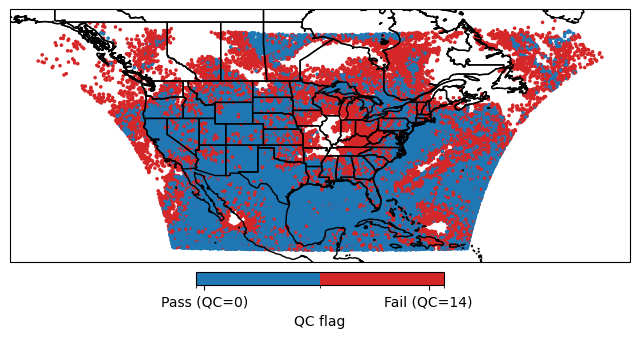

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.colors as mcolors

live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
fb_filename = f'{live_demo_path}/hofx/outputs/fb.hofx3d.filter.tempo_no2_tropo.20230809T150000Z.nc'
fb_file = xr.open_datatree(fb_filename)


var_name = 'nitrogendioxideColumn'
lat = fb_file['MetaData']['latitude']
lon = fb_file['MetaData']['longitude']
time = fb_file['MetaData']['dateTime']
qc = fb_file['EffectiveQC'][var_name]

fig = plt.figure(figsize=(8, 14))
ax = plt.axes(projection=ccrs.PlateCarree())

# Define discrete colors
qc_colors = ['tab:blue', 'tab:red']  # 0=pass, 14=fail
cmap = mcolors.ListedColormap(qc_colors)

# Define boundaries for the two values
bounds = [-0.5, 7, 15]
norm = mcolors.BoundaryNorm(bounds, cmap.N)


sc = ax.scatter(
    lon,
    lat,
    c=qc,
    cmap=cmap,
    norm=norm,
    s=10,
    marker='.',
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=1)

cbar = fig.colorbar(
    sc,
    ax=ax,
    orientation='horizontal',
    shrink=0.4,
    ticks=[0, 14],
    pad=0.01
)

cbar.ax.set_xticklabels(['Pass (QC=0)', 'Fail (QC=14)'])
cbar.set_label('QC flag')

plt.show()

## Ctest example

In the `fv3-jedi` repository, in [`test/CMakeLists.txt`](https://github.com/JCSDA/fv3-jedi/blob/develop/test/CMakeLists.txt) look for various H(x) test examples. For example, the ctest `fv3jedi_test_tier1_hofx_nomodel` uses `testinput/hofx_nomodel.yaml` as the YAML input and `fv3jedi_hofx_nomodel.x` as the executable. 

```yaml
ecbuild_add_test( TARGET   fv3jedi_test_tier1_hofx_nomodel
                  MPI      6
                  ARGS     testinput/hofx_nomodel.yaml
                  COMMAND  fv3jedi_hofx_nomodel.x )
```

Compare `testinput/hofx_nomodel.yaml` with the YAML file described in the example above and note the differences. 